<a href="https://colab.research.google.com/github/onyxs-prog/AI-ML-projects/blob/main/Intelligent_Traffic_Monitoring_and_Analysis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini-Project Title: Intelligent Traffic Monitoring and Analysis System**

## **Overview**
This project focuses on building an intelligent system for monitoring and analyzing traffic using **computer vision** and **machine learning** techniques. With the increasing number of vehicles on the road, manual traffic monitoring is inefficient and error-prone. Automating this process using AI ensures scalability, accuracy, and real-time analysis.

---

## **Objective**
Develop a computer vision-powered system that monitors traffic, detects vehicles, estimates traffic density, and analyzes traffic patterns. The system will use techniques like **object detection**, **tracking**, and **video analysis** to provide actionable insights for traffic management.

---

## **Learning Outcomes**
1. Understand computer vision techniques like **object detection**, **tracking**, and **video analysis**.
2. Explore deep learning models such as **YOLO** and **OpenCV** for traffic monitoring.
3. Learn to preprocess and analyze video data for traffic density estimation.
4. Gain experience in deploying computer vision models for real-time applications.
5. Develop skills in visualizing and interpreting traffic data.

---

## **Step 1: Define the Problem**
### **Task:**
Understand the problem and its real-world implications. Automating traffic monitoring using computer vision can improve traffic management, reduce congestion, and enhance road safety.

### **Mini-task:**
Write a brief paragraph on how computer vision benefits traffic management systems.


Computer vision enables real-time monitoring of traffic by automatically detecting vehicles, estimating traffic density, and identifying anomalies like accidents or traffic jams. This automation reduces the need for manual intervention, improves response times, and provides data-driven insights for better traffic management.

---

## **Step 2: Data Collection**
### **Task:**
Collect video data of traffic scenes suitable for analysis. Publicly available datasets such as the **UA-DETRAC dataset** or traffic surveillance videos from Kaggle can be used.

### **Mini-task:**
Download and load a suitable dataset for traffic monitoring.

```python
# Example: Load a video file for traffic analysis
import cv2

video_path = 'traffic_video.mp4'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    print("Video loaded successfully.")
```

---

## **Step 3: Exploratory Data Analysis (EDA)**
### **Task:**
Analyze the video data to understand traffic patterns, vehicle types, and density. Extract key frames and visualize traffic scenes.

### **Mini-task:**
Visualize the distribution of vehicle types and traffic density in the dataset.

```python
import matplotlib.pyplot as plt

# Example: Plot traffic density over time
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
density_over_time = []

for i in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        break
    # Perform vehicle detection and count (using YOLO or other models)
    # density_over_time.append(vehicle_count)

plt.plot(density_over_time)
plt.title("Traffic Density Over Time")
plt.xlabel("Frame Number")
plt.ylabel("Vehicle Count")
plt.show()
```

---

## **Step 4: Video Preprocessing**
### **Task:**
Preprocess the video data for analysis. Techniques include:
- Frame extraction
- Resizing and normalization
- Noise reduction

### **Mini-task:**
Extract and preprocess a few frames from the video.

```python
# Example: Extract and preprocess frames
def preprocess_frame(frame):
    frame = cv2.resize(frame, (640, 480))  # Resize frame
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    return frame

frames = []
for i in range(10):  # Extract first 10 frames
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(preprocess_frame(frame))

# Display a sample frame
plt.imshow(frames[0], cmap='gray')
plt.axis('off')
plt.show()
```

---

## **Step 5: Feature Engineering**
### **Task:**
Extract features from the video data for analysis. Techniques include:
- Vehicle detection using **YOLO**
- Traffic density estimation
- Vehicle tracking

### **Mini-task:**
Perform vehicle detection using a pre-trained YOLO model.

```python
from ultralytics import YOLO

# Load a pre-trained YOLO model
model = YOLO('yolov8n.pt')

# Perform vehicle detection on a frame
results = model(frames[0])

# Visualize the results
results[0].show()
```

---

## **Step 6: Model Training and Analysis**
### **Task:**
Train a model to analyze traffic patterns, such as predicting traffic density or detecting anomalies. Use classical machine learning models or deep learning models.

### **Mini-task:**
Train a simple model to classify traffic density (low, medium, high) based on vehicle counts.

```python
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Example: Train a traffic density classifier
X = np.array(density_over_time).reshape(-1, 1)  # Feature: vehicle count
y = np.where(X < 10, 0, np.where(X < 20, 1, 2))  # Labels: 0=low, 1=medium, 2=high

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
```

---

## **Step 7: Deployment and Visualization**
### **Task:**
Deploy the traffic monitoring system and visualize the results in real-time. Use tools like **OpenCV** for real-time visualization.

### **Mini-task:**
Create a real-time traffic monitoring dashboard using OpenCV.

```python
# Example: Real-time traffic monitoring
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Perform vehicle detection
    results = model(frame)
    annotated_frame = results[0].plot()

    # Display the annotated frame
    cv2.imshow('Traffic Monitoring', annotated_frame)
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
```

---

## **Optional: Advanced Techniques**
### **Task:**
Explore advanced techniques like:
- **Anomaly detection** (e.g., accidents or traffic jams)
- **Traffic flow prediction** using time series analysis
- **Integration with IoT devices** for real-time data collection

---

## **Conclusion**
This project provides a comprehensive approach to building an intelligent traffic monitoring and analysis system using **computer vision** and **machine learning**. By automating traffic monitoring, we can improve road safety, reduce congestion, and enhance traffic management.

---

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/highway-traffic-videos-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'highway-traffic-videos-dataset' dataset.
Path to dataset files: /kaggle/input/highway-traffic-videos-dataset


In [ ]:
import os

# List files and directories in the downloaded dataset path
print(os.listdir(path))

# You might need to explore subdirectories as well
for root, dirs, files in os.walk(path):
     print(root, files)

['EvalSet_train', 'traffic_patches_reg.mat', 'EvalSet.mat', 'info.txt', 'traffic_patches.mat', 'video', 'EvalSet_test', 'ImageMaster', 'README_TRAFFICDB', 'ImageMaster.mat']
/kaggle/input/highway-traffic-videos-dataset ['EvalSet_train', 'traffic_patches_reg.mat', 'EvalSet.mat', 'info.txt', 'traffic_patches.mat', 'EvalSet_test', 'ImageMaster', 'README_TRAFFICDB', 'ImageMaster.mat']
/kaggle/input/highway-traffic-videos-dataset/video ['cctv052x2004080618x00088.avi', 'cctv052x2004080610x01878.avi', 'cctv052x2004080516x01645.avi', 'cctv052x2004080517x01660.avi', 'cctv052x2004080518x01675.avi', 'cctv052x2004080617x00068.avi', 'cctv052x2004080611x01899.avi', 'cctv052x2004080613x00009.avi', 'cctv052x2004080609x01860.avi', 'cctv052x2004080607x01847.avi', 'cctv052x2004080516x01643.avi', 'cctv052x2004080610x01892.avi', 'cctv052x2004080606x01828.avi', 'cctv052x2004080608x01849.avi', 'cctv052x2004080618x00079.avi', 'cctv052x2004080519x01678.avi', 'cctv052x2004080619x00100.avi', 'cctv052x2004080610x

In [ ]:
# Example: Load a video file for traffic analysis
import cv2
import os

# Construct the full path to the video directory
video_dir = os.path.join(path, 'video')

# List the video files in the directory
video_files = [f for f in os.listdir(video_dir) if f.endswith('.avi')]

if video_files:
    # You can choose any video file from the list. Let's pick the first one for now.
    video_filename = video_files[0]
    video_path = os.path.join(video_dir, video_filename)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video file at {video_path}")
    else:
        print(f"Video loaded successfully from {video_filename}.")
else:
    print(f"Error: No .avi video files found in {video_dir}")

Video loaded successfully from cctv052x2004080618x00088.avi.



0: 480x640 5 cars, 1 boat, 6.6ms
Speed: 3.2ms preprocess, 6.6ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 cars, 1 truck, 9.5ms
Speed: 3.4ms preprocess, 9.5ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.6ms
Speed: 2.5ms preprocess, 6.6ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.1ms
Speed: 2.1ms preprocess, 6.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.2ms
Speed: 2.2ms preprocess, 6.2ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 6.1ms
Speed: 2.1ms preprocess, 6.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.1ms
Speed: 2.3ms preprocess, 6.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 6.2ms
Speed: 2.2ms preprocess, 6.2ms inference, 1.7ms postprocess per ima

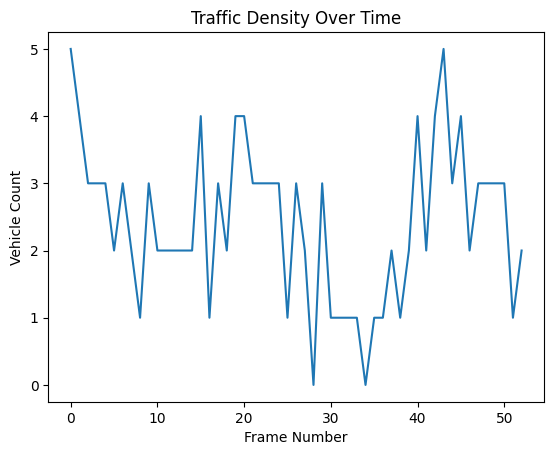

In [ ]:
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO # Import YOLO

# Make sure 'cap' is initialized from the previous cell
if 'cap' not in locals() or not cap.isOpened():
    print("Error: Video not loaded. Please run the previous cell to load the video.")
else:
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    density_over_time = []

    # Reset video capture to the beginning
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    # Load a pre-trained YOLO model (assuming 'model' is not already defined)
    if 'model' not in locals():
        model = YOLO('yolov8n.pt')


    for i in range(frame_count):
        ret, frame = cap.read()
        if not ret:
            break
        # Perform vehicle detection and count using YOLO
        results = model(frame)
        # Count the number of detected vehicles for the current frame
        vehicle_count = 0 # Initialize vehicle_count for the current frame
        for r in results:
            # Filter detections to include only vehicles (you might need to adjust class IDs based on the model)
            # YOLOv8 default classes: 'car': 2, 'truck': 7, 'bus': 5
            vehicle_classes = [2, 7, 5]
            for c in r.boxes.cls:
                if int(c) in vehicle_classes:
                    vehicle_count += 1


        density_over_time.append(vehicle_count)

    # Release the video capture object after processing
    cap.release()

    plt.plot(density_over_time)
    plt.title("Traffic Density Over Time")
    plt.xlabel("Frame Number")
    plt.ylabel("Vehicle Count")
    plt.show()

 This plot shows how the number of detected vehicles (cars, trucks, and buses, based on the class IDs specified in the code) changes over the frames of the video.

Each point on the line represents the total count of these vehicle types in a specific frame of the video. This visualization helps you understand the traffic density patterns throughout the video.

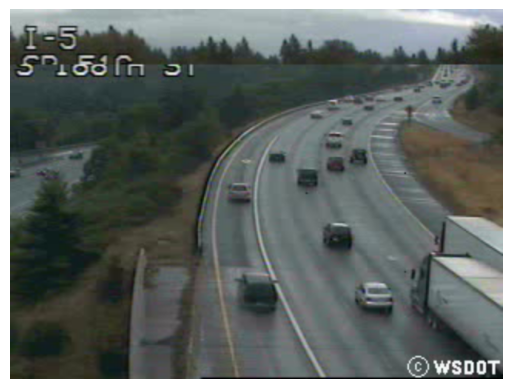

In [ ]:
# Example: Extract and preprocess frames
def preprocess_frame(frame):
    frame = cv2.resize(frame, (640, 480))  # Resize frame
    # frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale - REMOVED
    return frame

# Make sure 'cap' is initialized and open
if 'cap' not in locals() or not cap.isOpened():
    # Assuming video_path is still available from the previous cell
    if 'video_path' in locals():
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video file at {video_path}")
            # Exit if video cannot be opened
            exit()
    else:
        print("Error: Video path not defined. Please run the video loading cell first.")
        # Exit if video path is not defined
        exit()


frames = []
# Reset video capture to the beginning before extracting frames
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

for i in range(10):  # Extract first 10 frames
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(preprocess_frame(frame))

# Display a sample frame
if frames: # Check if frames list is not empty before trying to display
    # Display in color
    plt.imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("No frames were extracted from the video.")

# It's generally good practice to release the capture when done with it in a block
# cap.release() # Consider if you want to release here or keep open for next steps

In [ ]:
%pip install ultralytics


0: 480x640 5 cars, 1 boat, 8.4ms
Speed: 1.4ms preprocess, 8.4ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)


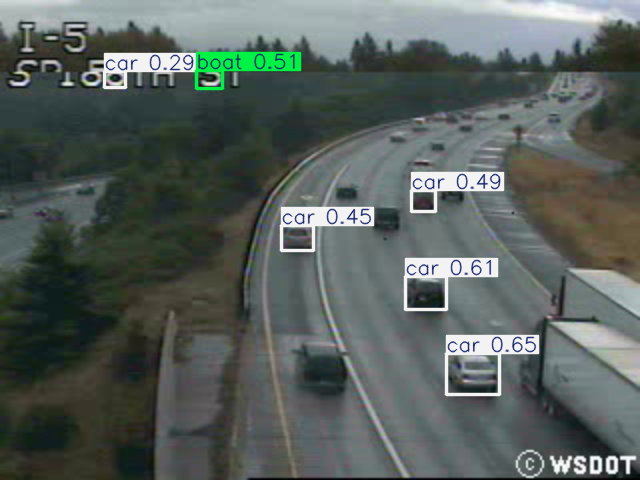

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLO model
model = YOLO('yolov8n.pt')

# Perform vehicle detection on a frame
results = model(frames[0])

# Visualize the results
results[0].show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Example: Train a traffic density classifier
X = np.array(density_over_time).reshape(-1, 1)  # Feature: vehicle count

# Define thresholds for traffic density levels (low, medium, high)
# Adjust these thresholds based on the range of vehicle counts in your video
low_threshold = 3
medium_threshold = 5

y = np.where(X < low_threshold, 0, np.where(X < medium_threshold, 1, 2))  # Labels: 0=low, 1=medium, 2=high

# Check the unique classes in y to diagnose the ValueError
unique_classes = np.unique(y)
print(f"Unique classes in y: {unique_classes}")

if len(unique_classes) < 2:
    print("Error: Not enough unique classes in the data to train the model.")
    print(f"Consider adjusting the thresholds ({low_threshold}, {medium_threshold}) or using a different video.")
else:
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Logistic Regression Model
    traffic_density_model = LogisticRegression() # Renamed from 'model'
    traffic_density_model.fit(X_train, y_train)

    # Predictions
    accuracy = traffic_density_model.score(X_test, y_test) # Use the new model name
    print(f"Model Accuracy: {accuracy * 100:.2f}%")

Unique classes in y: [0 1 2]
Model Accuracy: 90.91%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Example: Real-time traffic monitoring
import cv2
from ultralytics import YOLO

# Load a pre-trained YOLO model (if not already loaded or if it's not callable)
if 'model' not in locals() or not callable(model):
    print("Loading YOLO model...")
    model = YOLO('yolov8n.pt')
    print("YOLO model loaded.")


# Make sure 'cap' is initialized and open (if not already open)
if 'cap' not in locals() or not cap.isOpened():
    # Assuming video_path is still available from the previous cell
    if 'video_path' in locals():
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video file at {video_path}")
            # Exit if video cannot be opened
            exit()
    else:
        print("Error: Video path not defined. Please run the video loading cell first.")
        # Exit if video path is not defined
        exit()


while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Perform vehicle detection
    results = model(frame)
    annotated_frame = results[0].plot()

    # Display the annotated frame
    # cv2.imshow('Traffic Monitoring', annotated_frame) # This might not work in Colab
    # Alternative for Colab: Display frames periodically
    # from google.colab.patches import cv2_imshow
    # cv2_imshow(annotated_frame)

    # Add a small delay and check for key press
    if cv2.waitKey(1) & 0xFF == ord('q'): # Use waitKey(1) for video
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 5 cars, 1 boat, 6.4ms
Speed: 2.6ms preprocess, 6.4ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 cars, 1 truck, 6.2ms
Speed: 2.2ms preprocess, 6.2ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.1ms
Speed: 2.2ms preprocess, 6.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.2ms
Speed: 2.2ms preprocess, 6.2ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.1ms
Speed: 2.3ms preprocess, 6.1ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 6.1ms
Speed: 2.3ms preprocess, 6.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 1 truck, 6.1ms
Speed: 2.3ms preprocess, 6.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 cars, 6.1ms
Speed: 2.3ms preprocess, 6.1ms inference, 1.7ms postprocess per ima

When deploying a computer vision model to an external or production system, there are a few practical ways to go about it depending on the goal:

* **Edge Devices:** I can deploy the model on devices like Raspberry Pi or NVIDIA Jetson so the processing happens directly on-site. This usually means converting the model into a format the device supports and optimizing it to run smoothly.

* **Cloud Platforms:** Another option is deploying on cloud platforms like Google Cloud Platform (GCP), AWS, or Azure. I could use tools like Vertex AI or SageMaker, or even set up my own deployment using virtual machines or containers for more control.

* **Web Applications:** I can also integrate the model into a web app so users can upload videos or connect live streams for real-time analysis. This typically involves using frameworks like Flask or Django and exposing the model through an API.

* **Desktop Applications:** Lastly, I can build a standalone desktop app using something like PyQt or Tkinter, where the model runs locally on the user’s computer without relying on the cloud.
